In [17]:
import pandas as pd
import numpy as np

In [18]:
df=pd.read_csv('/content/raw_all_nodes.csv')
df

,Unnamed: 0,timestamp,devID,rain,soil,humi,temp,geo
0,0,11/1/2025 6:35,108,0.0,0.798555,66.650002,34.049999,0.000000
1,1,11/1/2025 6:36,108,0.0,0.534899,67.233335,34.233334,0.333333
2,2,11/1/2025 6:37,108,0.0,1.604698,65.700001,34.250000,1.000000
3,3,11/1/2025 6:38,108,0.0,1.604698,64.820000,34.260000,1.000000
4,4,11/1/2025 6:39,108,0.0,1.604698,63.940000,34.270000,1.000000
...,...,...,...,...,...,...,...,...
148914,148914,11/27/2025 16:35,106,0.0,46.400002,87.824999,22.700000,6.461545
148915,148915,11/27/2025 16:36,106,0.0,46.400002,87.699997,22.600000,0.277745
148916,148916,11/27/2025 16:37,106,0.0,46.400002,87.099998,22.700001,0.233911
148917,148917,11/27/2025 16:38,106,0.0,46.400002,87.850000,22.725000,0.248072


In [19]:
df=pd.read_csv('/content/raw_all_nodes.csv')
# 1. PREPROCESSING
# ---------------------------------------------------------
# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by devID and timestamp first to align past data correctly for the filter
df = df.sort_values(by=['devID', 'timestamp'])

# 2. CONFIGURATION
# ---------------------------------------------------------
# 1-minute intervals means:
# Rain 1 hour = 60 rows
# Soil 12 hours = 720 rows
# Geo 8 mins = 8 rows
smoothing_configs = [
    {'col': 'rain', 'window': 60},
    {'col': 'soil', 'window': 720},
    {'col': 'geo',  'window': 8}
]

# 3. APPLYING ONE-SIDED GAUSSIAN FILTER
# ---------------------------------------------------------
# Create a copy of the DataFrame to store smoothed values without overwriting originals
df_processed = df.copy()

for config in smoothing_configs:
    col = config['col']
    window_size = config['window']

    # Standard deviation (sigma) determines the curve width.
    # sigma = window / 6 covers +/- 3 std devs (99.7% of the curve)
    sigma = window_size / 6.0

    # Group by devID so we don't smooth across different devices
    # win_type=('gaussian', sigma) applies the weights with the specified standard deviation
    # center=False ensures we only look at present and past (one-sided)
    smoothed = df_processed.groupby('devID')[col].rolling(
        window=window_size,
        win_type=('gaussian', sigma),
        center=False
    ).mean()

    # Create new smoothed columns, stripping the multi-index created by groupby
    df_processed[f'{col}_smooth'] = smoothed.reset_index(level=0, drop=True)

# 4. FINAL SORTING
# ---------------------------------------------------------
# Sort by timestamp and devID as requested
df_processed = df_processed.sort_values(by=['timestamp', 'devID'])

# Display the head of the processed DataFrame
display(df_processed.head())

,Unnamed: 0,timestamp,devID,rain,soil,humi,temp,geo,rain_smooth,soil_smooth,geo_smooth
0,0,2025-11-01 06:35:00,108,0.0,0.798555,66.650002,34.049999,0.000000,NaN,NaN,NaN
1,1,2025-11-01 06:36:00,108,0.0,0.534899,67.233335,34.233334,0.333333,NaN,NaN,NaN
2,2,2025-11-01 06:37:00,108,0.0,1.604698,65.700001,34.250000,1.000000,NaN,NaN,NaN
3,3,2025-11-01 06:38:00,108,0.0,1.604698,64.820000,34.260000,1.000000,NaN,NaN,NaN
4,4,2025-11-01 06:39:00,108,0.0,1.604698,63.940000,34.270000,1.000000,NaN,NaN,NaN


In [30]:
df_processed.to_csv('/content/Guassian_filter_all_nodes.csv')

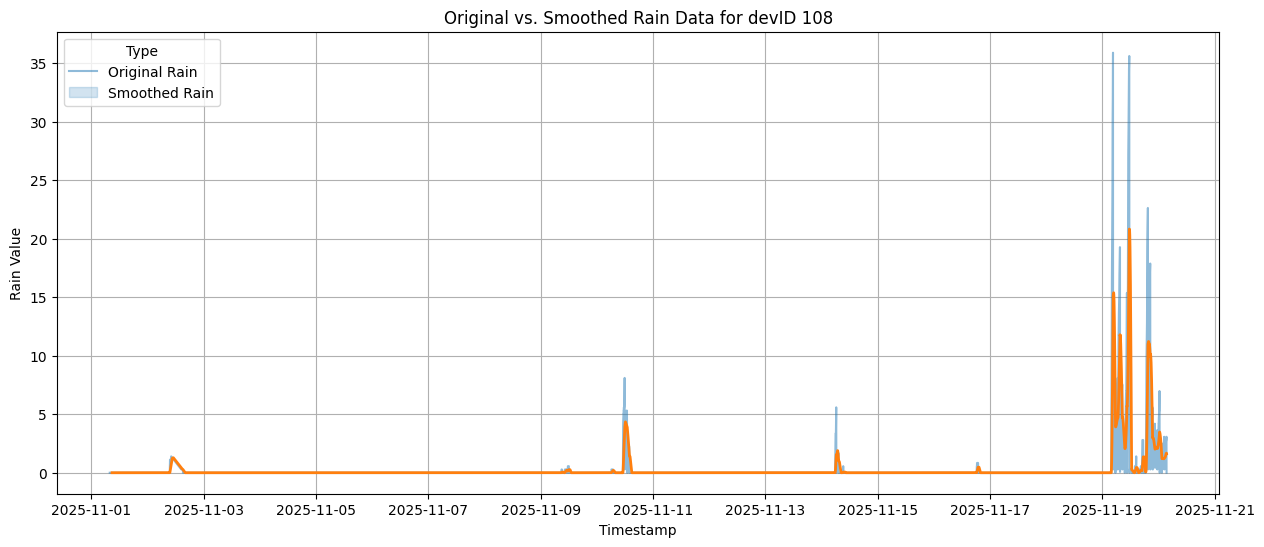

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for devID 108
df_dev108 = df_processed[df_processed['devID'] == 107]

# Plotting rain and rain_smooth for devID 108
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_dev108, x='timestamp', y='rain', alpha=0.5)
sns.lineplot(data=df_dev108, x='timestamp', y='rain_smooth', linewidth=2)
plt.title('Original vs. Smoothed Rain Data for devID 108')
plt.xlabel('Timestamp')
plt.ylabel('Rain Value')
plt.legend(['Original Rain', 'Smoothed Rain'], title='Type')
plt.grid(True)
plt.show()

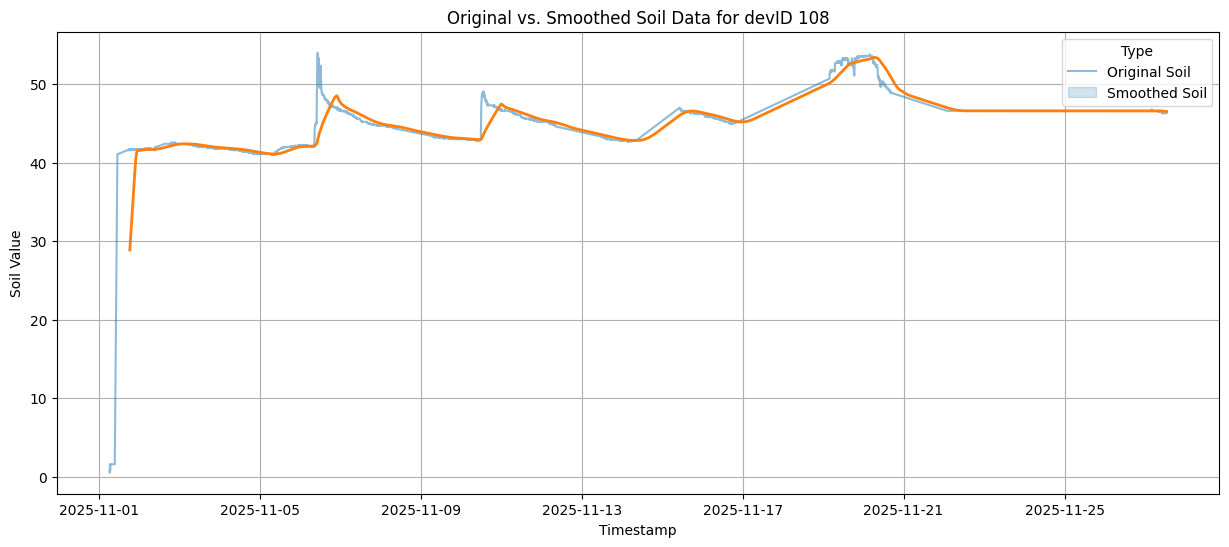

In [43]:
# Filter data for devID 108
df_dev108 = df_processed[df_processed['devID'] == 108]

# Plotting soil and soil_smooth for devID 108
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_dev108, x='timestamp', y='soil', alpha=0.5)
sns.lineplot(data=df_dev108, x='timestamp', y='soil_smooth', linewidth=2)
plt.title('Original vs. Smoothed Soil Data for devID 108')
plt.xlabel('Timestamp')
plt.ylabel('Soil Value')
plt.legend(['Original Soil', 'Smoothed Soil'], title='Type')
plt.grid(True)
plt.show()

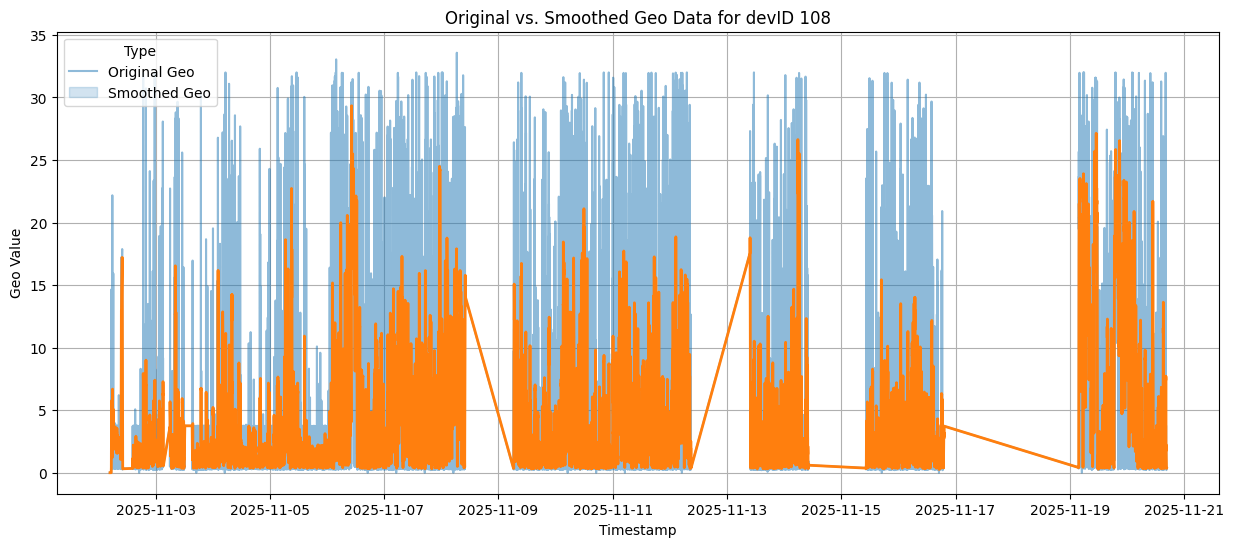

In [48]:
# Filter data for devID 108
df_dev108 = df_processed[df_processed['devID'] == 109]

# Plotting geo and geo_smooth for devID 108
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_dev108, x='timestamp', y='geo', alpha=0.5)
sns.lineplot(data=df_dev108, x='timestamp', y='geo_smooth', linewidth=2)
plt.title('Original vs. Smoothed Geo Data for devID 108')
plt.xlabel('Timestamp')
plt.ylabel('Geo Value')
plt.legend(['Original Geo', 'Smoothed Geo'], title='Type')
plt.grid(True)
plt.show()

In [20]:
df_processed

,Unnamed: 0,timestamp,devID,rain,soil,humi,temp,geo,rain_smooth,soil_smooth,geo_smooth
0,0,2025-11-01 06:35:00,108,0.0,0.798555,66.650002,34.049999,0.000000,NaN,NaN,NaN
1,1,2025-11-01 06:36:00,108,0.0,0.534899,67.233335,34.233334,0.333333,NaN,NaN,NaN
2,2,2025-11-01 06:37:00,108,0.0,1.604698,65.700001,34.250000,1.000000,NaN,NaN,NaN
3,3,2025-11-01 06:38:00,108,0.0,1.604698,64.820000,34.260000,1.000000,NaN,NaN,NaN
4,4,2025-11-01 06:39:00,108,0.0,1.604698,63.940000,34.270000,1.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
148914,148914,2025-11-27 16:35:00,106,0.0,46.400002,87.824999,22.700000,6.461545,0.0,46.640156,9.447857
148915,148915,2025-11-27 16:36:00,106,0.0,46.400002,87.699997,22.600000,0.277745,0.0,46.639323,9.006634
148916,148916,2025-11-27 16:37:00,106,0.0,46.400002,87.099998,22.700001,0.233911,0.0,46.638490,7.718363
148917,148917,2025-11-27 16:38:00,106,0.0,46.400002,87.850000,22.725000,0.248072,0.0,46.637656,5.371349
